In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
import sys
from IPython.display import Image
import seaborn
import pandas as pd
import itertools
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.metrics import r2_score
from multipledispatch import dispatch

seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080']
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm")
sys.path.append(src_dir)
#sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.11/site-packages/q2mm-0.0.0-py3.11.egg")


from tools.ff_plotting import *

**Rhodium-catalyzed Hydrogenation of Enamides TSFF Parameterized via FUERZA Projections & Subsequent Gradient Optimization**

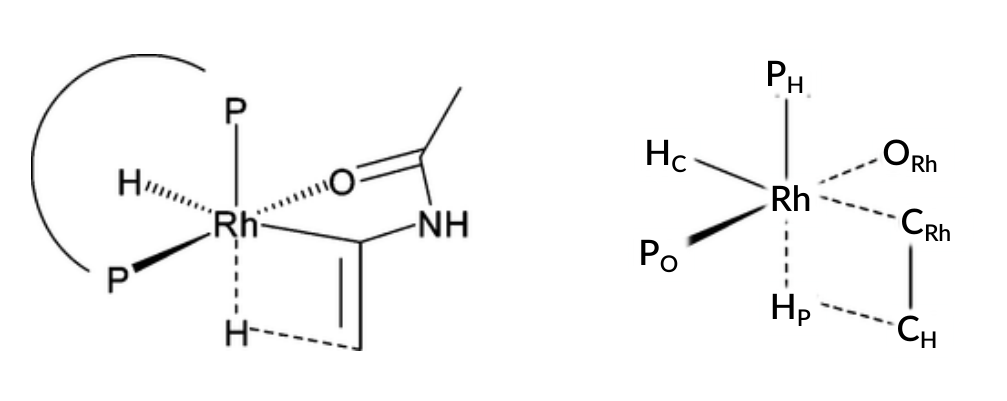

In [2]:
Image(filename='/home/mfarrugi/Documents/Rh_figures/rh_system_defn.png')

In [3]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]
score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 1, 106390, 106391, 106392, 106393, 106394, 106395, 106396, 106397, 106398, 106399, 106400, 106401]
bond_rows = np.arange(1859, 1867)
angle_rows = np.concatenate((np.arange(1867, 1889), [1908]))
bonds_rows = [str(bond_row+1) for bond_row in bond_rows]
angles_rows = [str(angle_row+1) for angle_row in angle_rows]
ff_rows = np.concatenate((bond_rows, angle_rows))
ffs_rows = [str(ff_row + 1) for ff_row in ff_rows]
rows = [*bond_rows, *angle_rows]
convergence_criteria = 0.001
num_params = 31
substructure_strings = ['HX-RH(-PX)-HX.C2*C2(.2)-N2-C2=O2.2', 'RH-PX']
param_names = ['Hc-Rh', 'Rh-P\u2095', 'Rh-P\u2092', 'Rh-H\u209A', 'Rh.CRh', 'Rh.ORh', 'H\u209A.C\u2095', 'C\u2095*CRh', 'Hc-Rh-P\u2095', 'Hc-Rh-P\u2092', 'Hc-Rh-H\u209A', 'Hc-Rh.CRh', 'Hc-Rh.ORh', 'P\u2095-Rh-H\u209A', 'P\u2092-Rh-H\u209A', 'P\u2095-Rh.CRh', 'P\u2092-Rh.CRh', 'P\u2095-Rh.ORh','P\u2092-Rh.ORh', 'H\u209A-Rh.CRh', 'H\u209A-Rh.ORh', 'CRh.Rh.ORh', 'Rh-H\u209A.C\u2095', 'H\u209A.C\u2095*00', 'CRh*C\u2095.H\u209A', 'Rh.CRh*C0', 'Rh.CRh*C2o', 'Rh.CRh*C\u2095', 'Rh.CRh-N2', 'Rh.ORh=C2', 'P\u209A-Rh-P\u2095']
bond_label_list = param_names[:8]
angle_label_list = param_names[8:]

base_direc = os.getcwd()

# Scores

## unoptimized data
static_score = 6.3751
static_scores = pd.read_csv('q_static/rh_qstatic_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn: '+str(static_score))
fuerza_score = 1.36077746
fuerza_scores = pd.read_csv('q_fuerza/rh_qf_grad_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
gamma_fuerza_score = 1.1431
gamma_fuerza_scores = pd.read_csv('gamma_q_fuerza/uninv.score.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA: '+str(gamma_fuerza_score))
ffuerza_score = 1.0054
ffuerza_scores = pd.read_csv('q_frankenfuerza/uninv.score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='QFUERZA: '+str(ffuerza_score))
donoghue_score = 3.4894
donoghue_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/rh_donoghue_final_scores.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)
uninv_fuerza_score = 1.2765
uninv_fuerza_scores = pd.read_csv('uninv_q_fuerza/inv.score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='UNINVFUERZA: '+str(uninv_fuerza_score))

## optimized data
normal_grad_score = 0.8135
normal_grad_scores = pd.read_csv('q_static/rh_static_grad_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Approxn-GRAD: '+str(normal_grad_score))
fuerza_grad_score = 0.8125
fuerza_grad_scores = pd.read_csv('q_fuerza/rh_qf_grad_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA-GRAD: '+str(fuerza_grad_score))
gamma_fuerza_grad_score = 0.8132
gamma_fuerza_grad_scores = pd.read_csv('gamma_q_fuerza/rh_qgf_inveig_grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=r'$\mathit{\gamma}$-FUERZA-GRAD: '+str(gamma_fuerza_grad_score))
ffuerza_grad_score = 0.8128
ffuerza_grad_scores = pd.read_csv('q_frankenfuerza/rh_qff_inveig_grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='QFUERZA-GRAD: '+str(ffuerza_grad_score))
donoghue_grad_score = 0.8183
donoghue_grad_scores = pd.read_csv('~/repos/q2mm/rh-hybrid/conv_crit/local_best_x/20_part_200_iter/donoghue_grad/uninv_eig/rh_don_grad_eig_end.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF=donoghue_score)


# Bonds

## unoptimized
bond_normal = pd.read_csv('q_static/rh_static_start.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score).assign(Parameter=bond_label_list) 
angle_normal = pd.read_csv('q_static/rh_static_start.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score).assign(Parameter=angle_label_list)
bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, ['q_fuerza'], 'rh_hyd_enamide_q_seminario.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')
bond_fuerza = bond_fuerza[0].assign(Parameter=bond_label_list) 
angle_fuerza = angle_fuerza[0].assign(Parameter=angle_label_list)
bond_gamma_fuerza, gamma_angle_fuerza, param_gamma_fuerza = get_ff_params(base_direc, ['gamma_q_fuerza'], 'gamma_q_fuerza.fld', [gamma_fuerza_score], bond_rows, angle_rows, r'$\mathit{\gamma}$-FUERZA')
gamma_angle_fuerza = gamma_angle_fuerza[0].assign(Parameter=angle_label_list)
bond_ffuerza, angle_ffuerza, param_ffuerza = get_ff_params('q_frankenfuerza', [''], 'q_frankenfuerza_H.fld', [ffuerza_score], bond_rows, angle_rows, 'QFUERZA')
angle_ffuerza = angle_ffuerza[0].assign(Parameter=angle_label_list)
bond_don = pd.read_csv('donoghue/donoghue_0mods.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score).assign(Parameter=bond_label_list)
angle_don = pd.read_csv('donoghue/donoghue_0mods.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_score).assign(Parameter=angle_label_list)
params_don = pd.concat([bond_don, angle_don])
#melted_params_don = pd.melt(params_don, id_vars=['param_type', 'atom1', 'atom2', 'atom3', 'ff_row'], value_vars=['Force Constant'])

bond_uninvqf = pd.read_csv('uninv_q_fuerza/rh_uninv_qf_start.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score)
angle_uninvqf = pd.read_csv('uninv_q_fuerza/rh_uninv_qf_start.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score)

## optimized
bond_normal_grad = pd.read_csv('q_static/rh_static_grad_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=normal_grad_score).assign(Parameter=bond_label_list) 
angle_normal_grad = pd.read_csv('q_static/rh_static_grad_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=normal_grad_score).assign(Parameter=angle_label_list)
bond_fuerza_grad = pd.read_csv('q_fuerza/rh_qf_grad_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_grad_score).assign(Parameter=bond_label_list) 
angle_fuerza_grad = pd.read_csv('q_fuerza/rh_qf_grad_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_grad_score).assign(Parameter=angle_label_list)
#TODO run below optimization
gamma_bond_fuerza_grad = pd.read_csv('gamma_q_fuerza/rh_qgf_inveig_grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=gamma_fuerza_score).assign(Parameter=bond_label_list) 
gamma_angle_fuerza_grad = pd.read_csv('gamma_q_fuerza/rh_qgf_inveig_grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=gamma_fuerza_score).assign(Parameter=angle_label_list)
bond_ffuerza_grad = pd.read_csv('q_frankenfuerza/rh_qff_inveig_grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=ffuerza_grad_score).assign(Parameter=bond_label_list) 
angle_ffuerza_grad = pd.read_csv('q_frankenfuerza/rh_qff_inveig_grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=ffuerza_grad_score).assign(Parameter=angle_label_list)

# ## unoptimized
# bond_normal = pd.read_csv('q_static/mm3.static.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=static_score)
# angle_normal = pd.read_csv('q_static/mm3.static.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=static_score)
# bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, ['q_fuerza'], 'rh_hyd_enamide_q_seminario.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')
# bond_fuerza = bond_fuerza[0]
# angle_fuerza = angle_fuerza[0]
# bond_gamma_fuerza, gamma_angle_fuerza, param_gamma_fuerza = get_ff_params(base_direc, ['gamma_q_fuerza'], 'Rh TSFF_gamma_fuerza.fld', [gamma_fuerza_score], bond_rows, angle_rows, r'$\mathit{\gamma}$-FUERZA')
# gamma_angle_fuerza = gamma_angle_fuerza[0]
# bond_ffuerza, angle_ffuerza, param_ffuerza = get_ff_params('frankenfuerza', [''], 'q_frankenfuerza_H.fld', [ffuerza_score], bond_rows, angle_rows, 'QFUERZA')
# angle_ffuerza = angle_ffuerza[0]
# bond_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=donoghue_score)
# angle_don = pd.read_csv('/home/mfarrugi/repos/q2mm/rh-hybrid/ff/rh_hyd_enamide_final.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=donoghue_score)
# bond_don = bond_don.assign(ff_row=bonds_rows).assign(atom3='-')
# angle_don = angle_don.assign(ff_row=angles_rows)
# params_don = pd.concat([bond_don, angle_don])
# melted_params_don = pd.melt(params_don, id_vars=['param_type', 'atom1', 'atom2', 'atom3', 'ff_row'], value_vars=['Force Constant'])

# ## optimized
# bond_normal_grad = pd.read_csv('q_static/mm3.static.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=normal_grad_score)
# angle_normal_grad = pd.read_csv('q_static/mm3.static.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=normal_grad_score)
# bond_fuerza_grad = pd.read_csv('q_fuerza/rh_qf_grad_end.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_grad_score)
# angle_fuerza_grad = pd.read_csv('q_fuerza/rh_qf_grad_end.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_grad_score)
# gamma_bond_fuerza_grad = pd.read_csv('gamma_q_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=gamma_fuerza_score)
# gamma_angle_fuerza_grad = pd.read_csv('gamma_q_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=gamma_fuerza_score)
# bond_ffuerza_grad = pd.read_csv('q_frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=ffuerza_grad_score)
# angle_ffuerza_grad = pd.read_csv('q_frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=ffuerza_grad_score)

bonds = [bond_fuerza, bond_fuerza, bond_fuerza, bond_normal_grad, bond_fuerza_grad, gamma_bond_fuerza_grad, bond_ffuerza_grad]
angles = [angle_fuerza, gamma_angle_fuerza, angle_ffuerza, angle_normal_grad, angle_fuerza_grad, angle_ffuerza_grad, gamma_angle_fuerza_grad]
eigenmatrix_scores = [static_scores, fuerza_scores, gamma_fuerza_scores, ffuerza_scores, normal_grad_scores, fuerza_grad_scores, gamma_fuerza_grad_scores, ffuerza_grad_scores]
score_sums = ['Approxn: '+'{0:.3f}'.format(static_score), 'FUERZA: '+'{0:.3f}'.format(fuerza_score), r'$\mathit{\gamma}$-FUERZA: '+'{0:.3f}'.format(gamma_fuerza_score), 'QFUERZA: '+'{0:.3f}'.format(ffuerza_score), 'Approxn-GRAD: '+'{0:.3f}'.format(normal_grad_score), 'FUERZA-GRAD: '+'{0:.3f}'.format(fuerza_grad_score), r'$\mathit{\gamma}$-FUERZA-GRAD: '+'{0:.3f}'.format(gamma_fuerza_grad_score), 'QFUERZA-GRAD: '+'{0:.3f}'.format(ffuerza_grad_score)]

In [4]:
@dispatch(plt.Axes)
def style_per_plot_legends(axes:list):# -> list:
    for ax in axes:
        ax.legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=1., handletextpad=0.)
    return axes

@dispatch(list)
def style_fig_legend(axes:list):
    for ax in axes:
        ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return axes

@dispatch(plt.Axes)
def style_fig_legend(axes:plt.Axes):
    ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)
    return ax

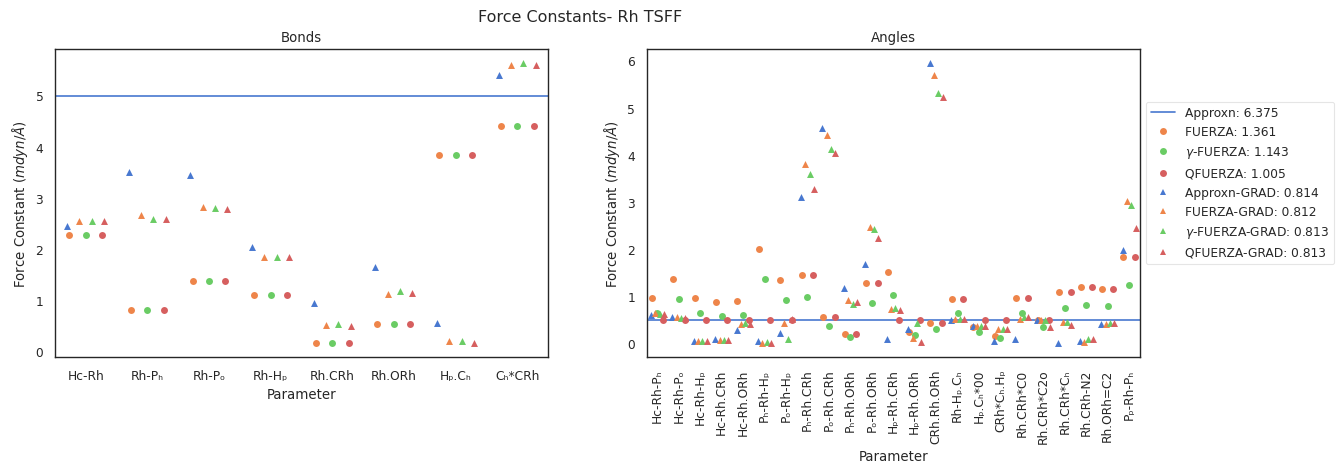

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [5]:
plot_ff_params_v_static(bonds, angles, score_sums[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

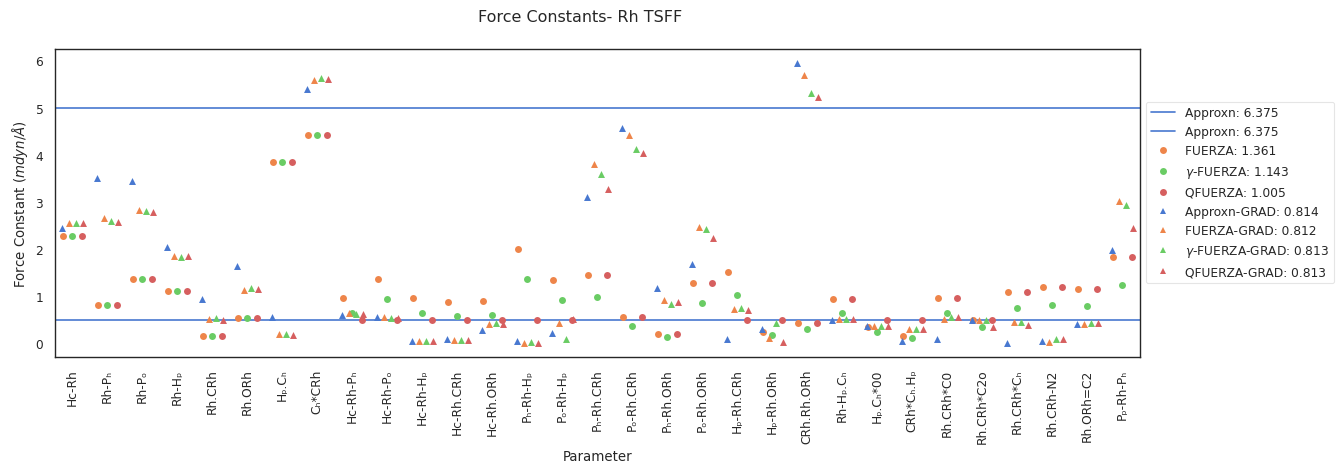

(<Figure size 1400x400 with 1 Axes>,
 <Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>)

In [6]:
plot_ff_params_v_static_(bonds, angles, score_sums[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

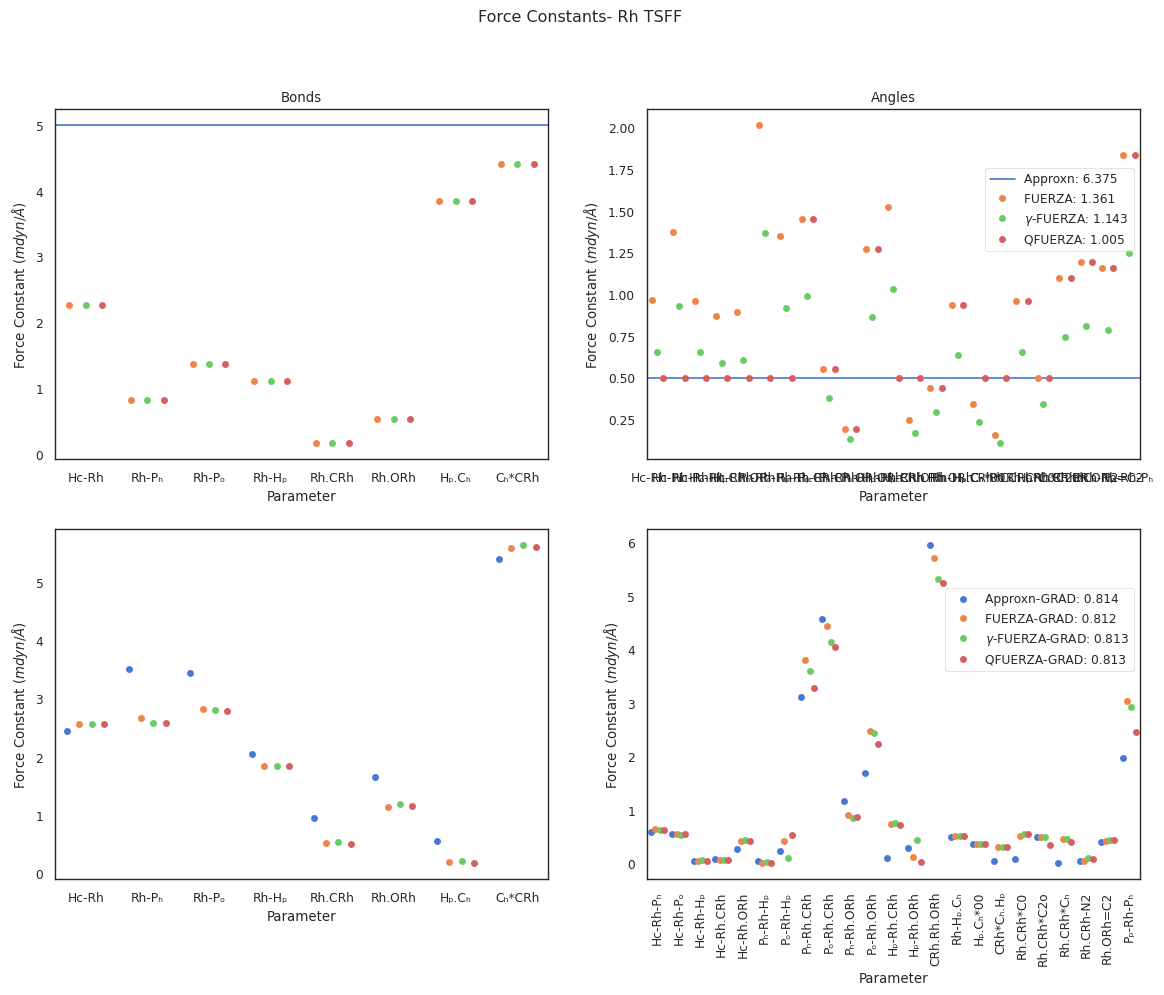

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
         <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
        [<Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
         <Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>]],
       dtype=object))

In [7]:
compare_opt_params(bonds, angles, score_sums[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

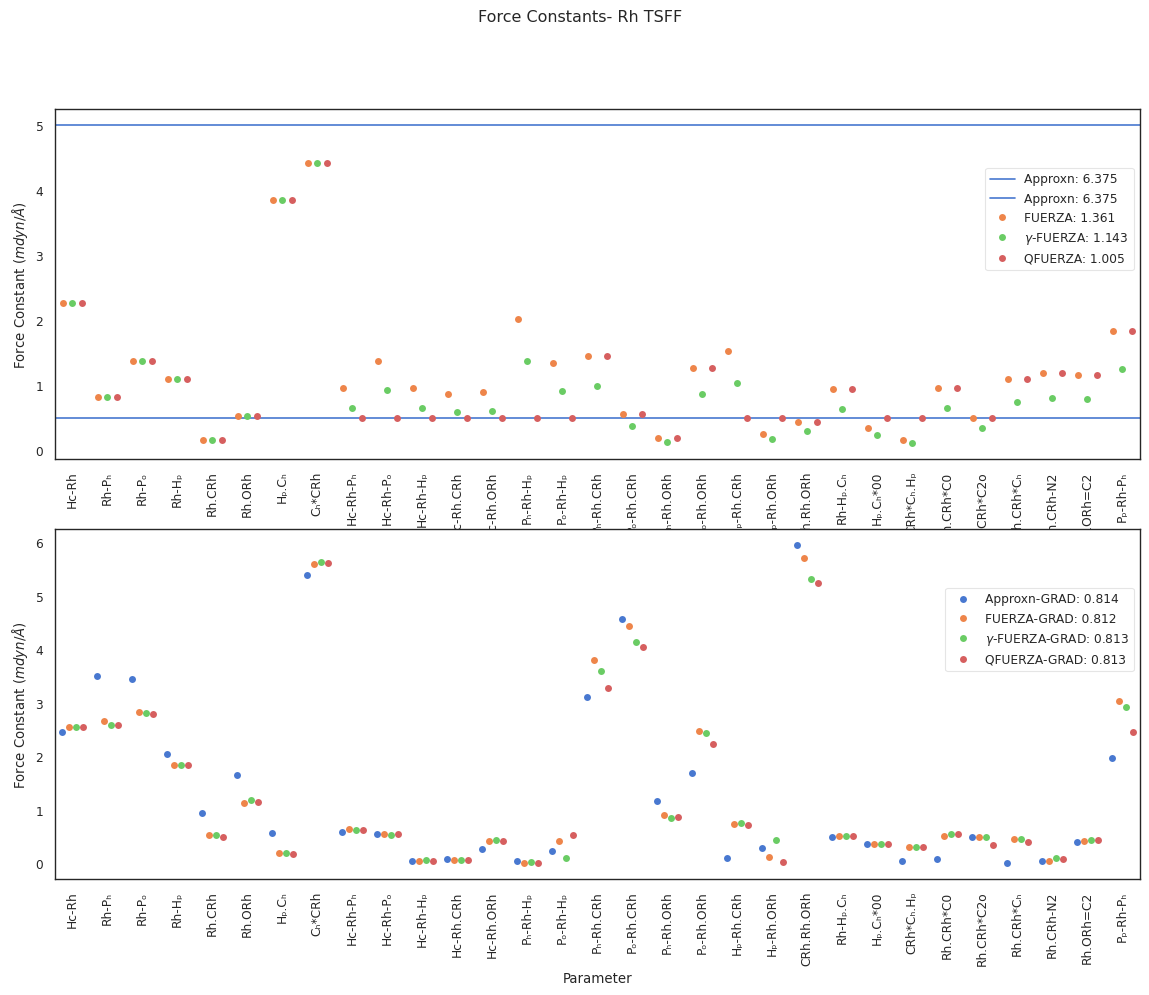

(<Figure size 1400x1000 with 2 Axes>,
 array([<Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [8]:
compare_opt_params_(bonds, angles, score_sums[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

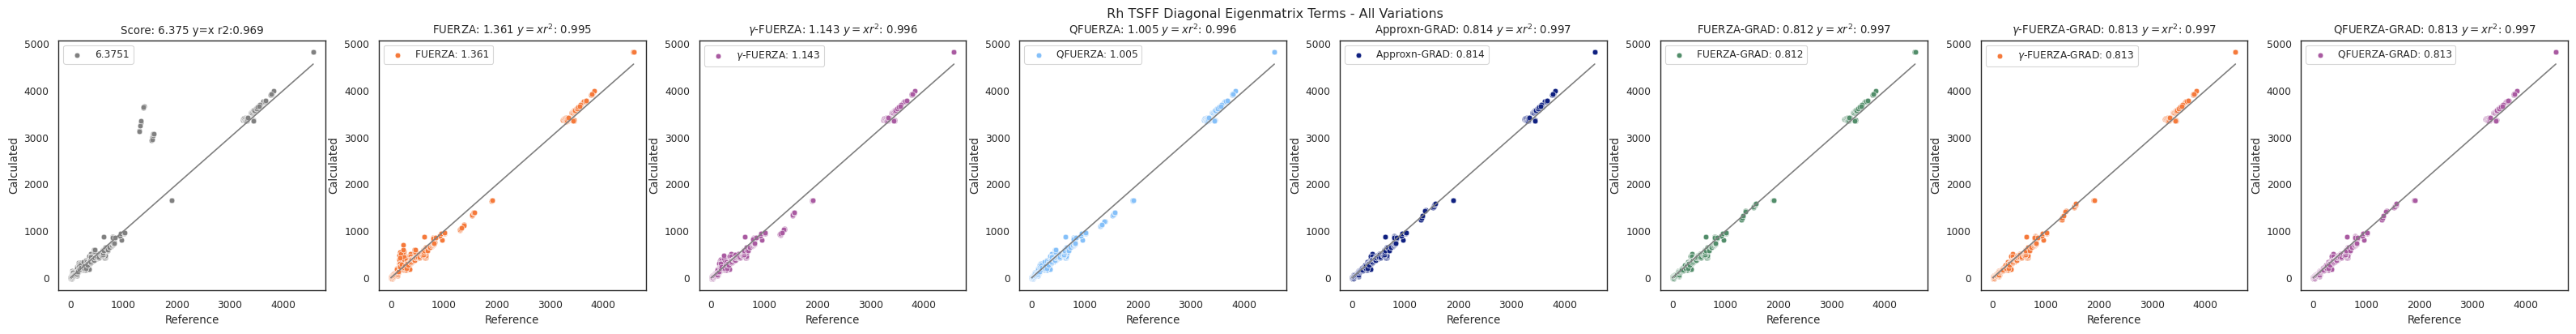

In [9]:
linear_fit_diag_scores(static_scores, static_score, eigenmatrix_scores[1:], score_sums[1:], ' Rh TSFF Diagonal Eigenmatrix Terms - All Variations')

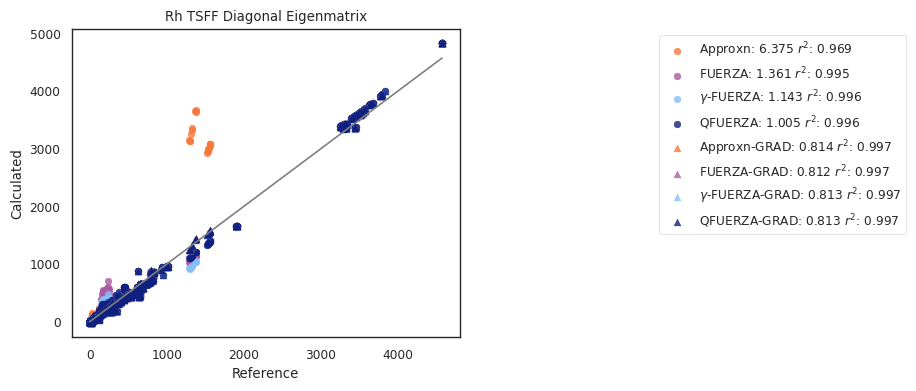

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5,4))
ax.set_title('Rh TSFF Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))


for eigenmatrix, score in zip(eigenmatrix_scores, score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
    else:
        marker = "o"
        color = next(palette)
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax, marker=marker, alpha = 0.8)

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax)
ax = ax.legend(bbox_to_anchor=(1.5, 1), fancybox=True, framealpha=0.5)

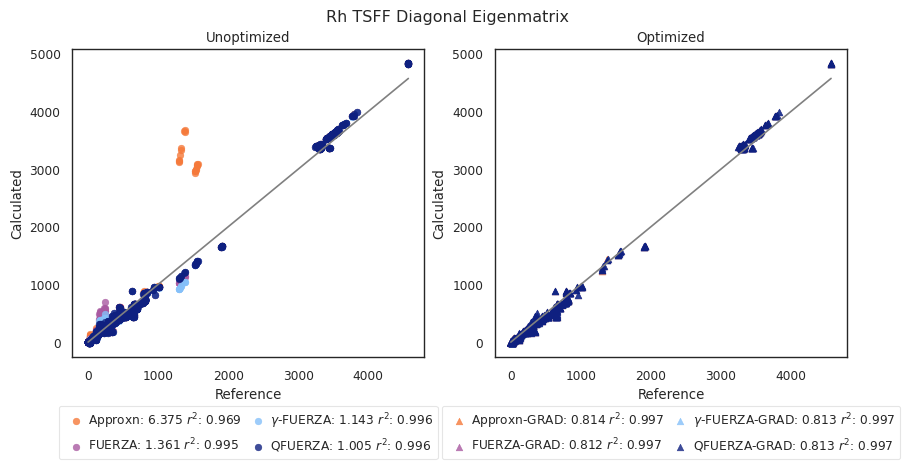

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Rh TSFF Diagonal Eigenmatrix')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))
palette_opt = itertools.cycle(seaborn.color_palette(palette=zesty))

r2_scores = []
r2_score_labels = []

for eigenmatrix, score in zip(eigenmatrix_scores, score_sums):
    diag = eigenmatrix.loc[eigenmatrix['Reference'] != 0.0000]
    diag = diag.loc[diag['Weight'] != 0.0000]
    #slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
    r2_ = r2_score(diag['Reference'], diag['Calculated'])
    r2_scores.append(r2_)
    if any(opt_flag in score for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
        marker="^"
        color = next(palette_opt)
        axis=1
    else:
        marker = "o"
        color = next(palette)
        axis=0
    seaborn.scatterplot(data=diag, y='Calculated', x='Reference', color=color, edgecolor=color, label=score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)), ax=ax[axis], marker=marker, alpha = 0.8)
    r2_score_labels.append(score + r' $r^{2}$: '+str(np.round(r2_, decimals=3)))

seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[0])
seaborn.lineplot(data=diag, x='Reference', y='Reference', color='gray', ax=ax[1])
ax[0].set_title('Unoptimized')
ax[1].set_title('Optimized')
ax[0].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)
ax[1].legend(bbox_to_anchor=(0.5, -0.35), loc='lower center', fancybox=True, framealpha=0.5, ncol=2, columnspacing=0.3, handletextpad=0.)

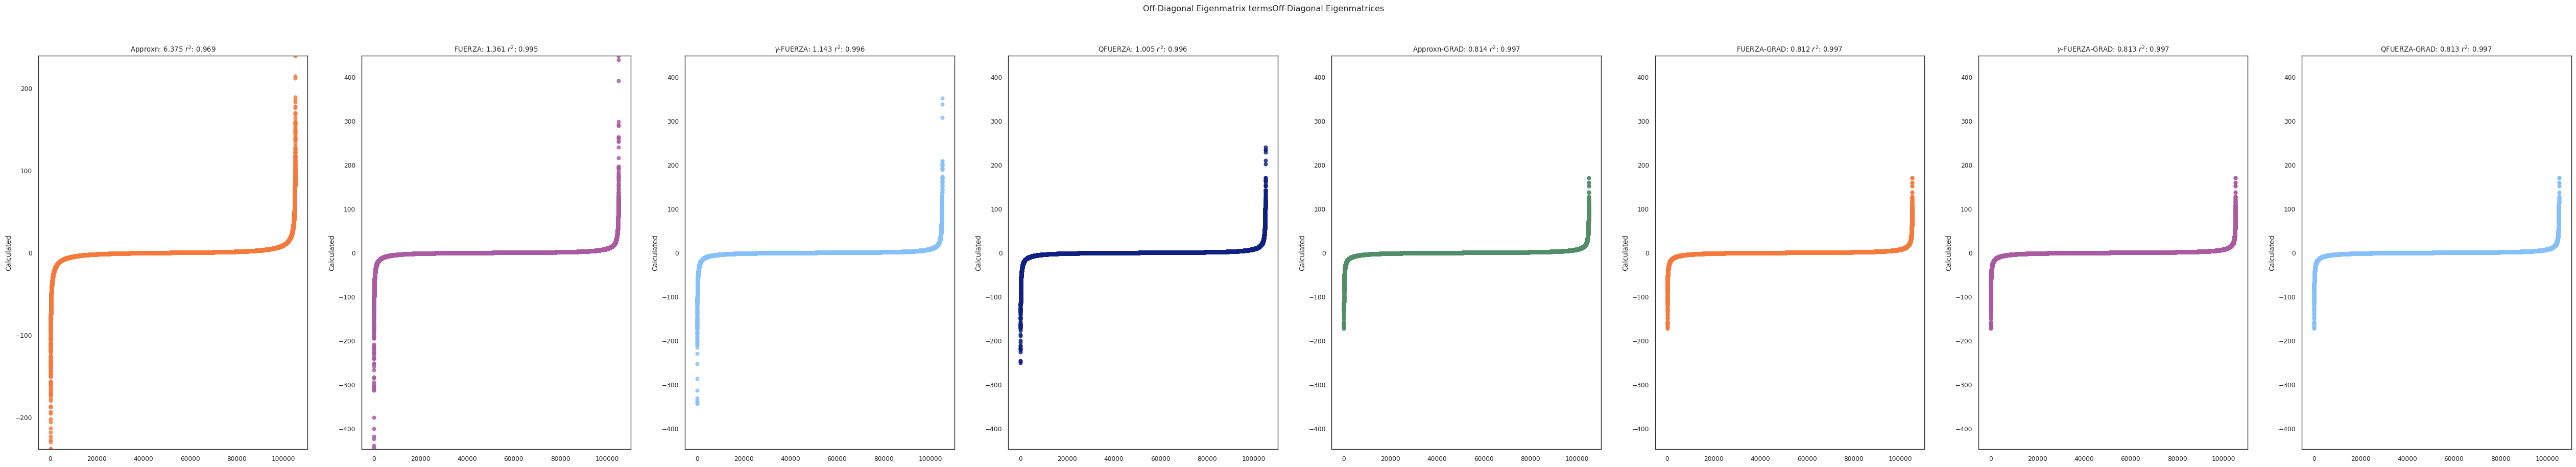

In [12]:
plot_off_diag_scatter(eigenmatrix_scores, r2_score_labels, 'Off-Diagonal Eigenmatrices')

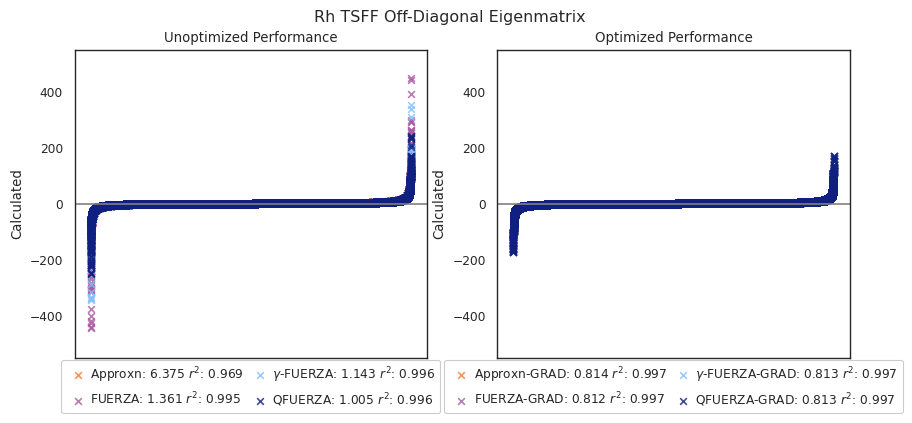

In [13]:
def off_diag_scatter(score_matrices:list, total_scores:list, title:str=''):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle('Rh TSFF Off-Diagonal Eigenmatrix'+title)
    palette = itertools.cycle(zesty_palette)
    palette_opt = itertools.cycle(zesty_palette)
    max_y = 0.

    for i, run in enumerate(score_matrices):
        off_diag = run.loc[run['Reference'] == 0.0000]
        off_diag = off_diag.loc[off_diag['Weight'] != 0.0000]
        off_diag = off_diag.sort_values(by='Calculated', ignore_index=True)

        if any(opt_flag in total_scores[i] for opt_flag in ['Opt', 'OPT', 'GRAD', 'HO']):
            color = next(palette_opt)
            axis=1
        else:
            color = next(palette)
            axis=0
        
        seaborn.regplot(data=off_diag, x=off_diag.index, label=r2_score_labels[i], y='Calculated', marker='x', fit_reg=False, ax=ax[axis], color=color)
        max_y = max(max_y, max(off_diag['Calculated']))

    max_y = max_y + 100
    ax[0].set_ylim(top=max_y, bottom=-max_y)
    ax[1].set_ylim(top=max_y, bottom=-max_y)
    ax[0].set_title('Unoptimized Performance')
    ax[1].set_title('Optimized Performance')
    ax[0].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[1].legend(bbox_to_anchor=(0.5, -0.2), loc='lower center', fancybox=True, framealpha=1, ncol=2, columnspacing=0.3, handletextpad=0.)
    ax[0].axhline(y=0, color='gray')
    ax[1].axhline(y=0, color='gray')
    plt.show()

off_diag_scatter(eigenmatrix_scores, score_sums)

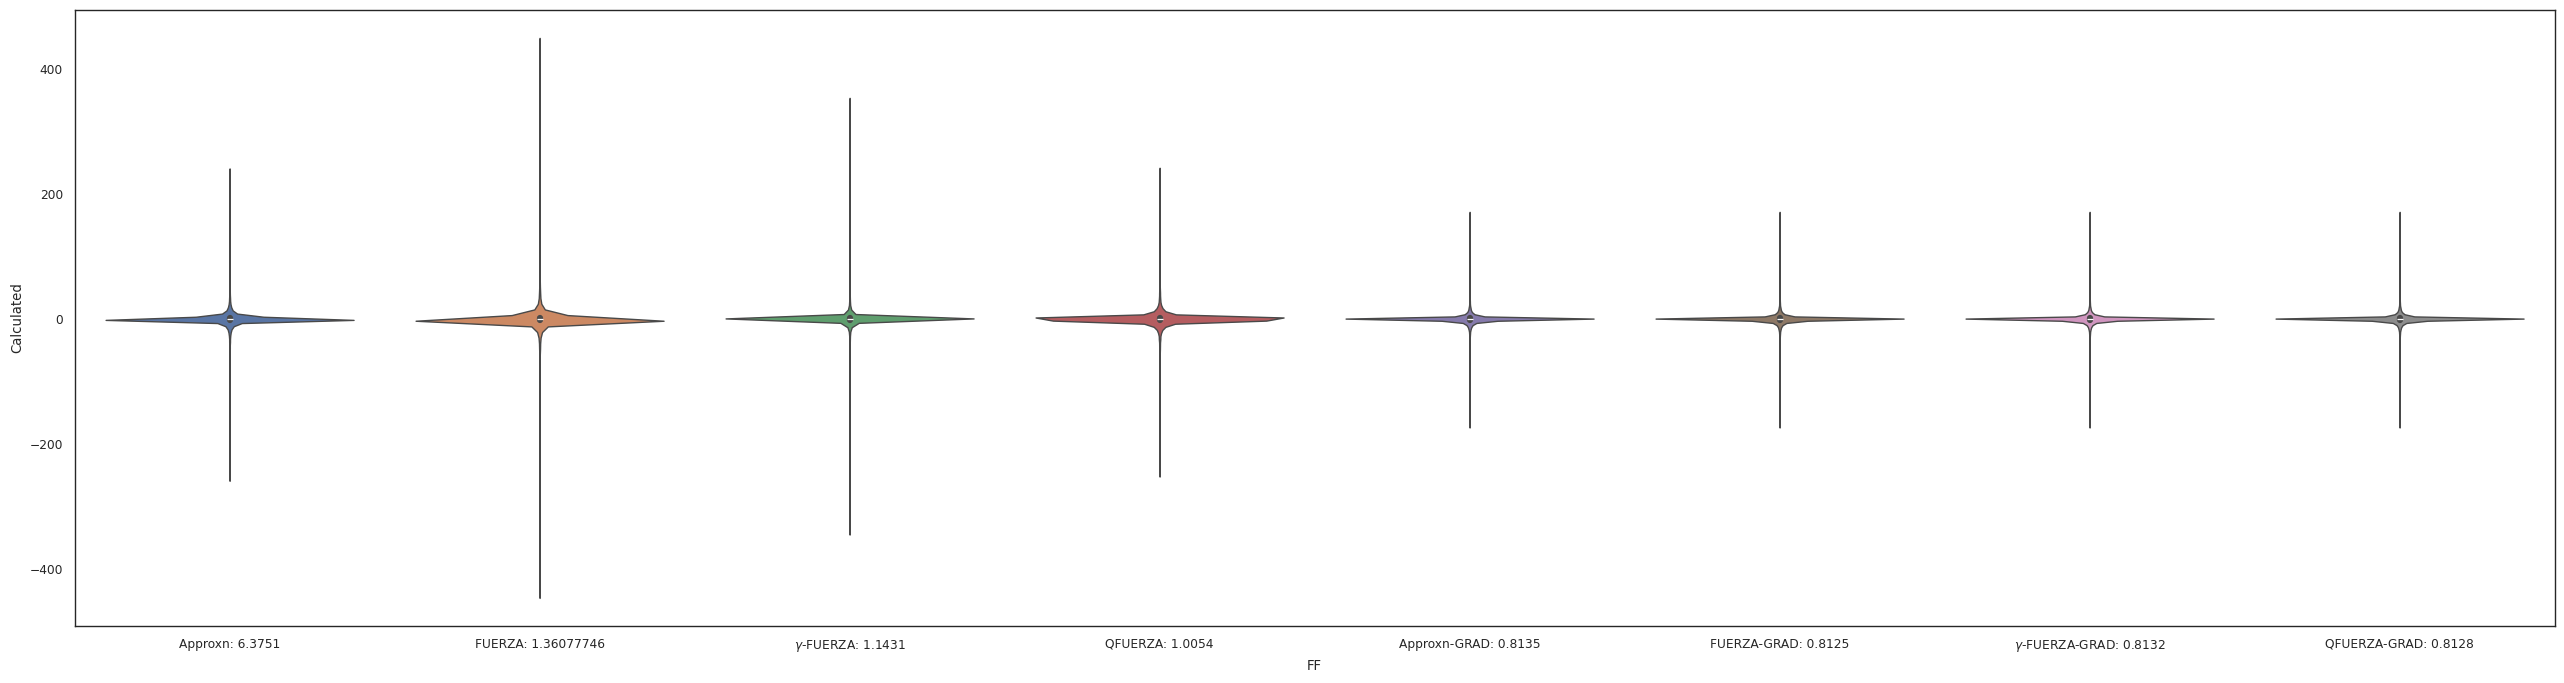

In [14]:
plot_off_diag_violin(static_scores, static_score, eigenmatrix_scores[1:], score_sums[1:])

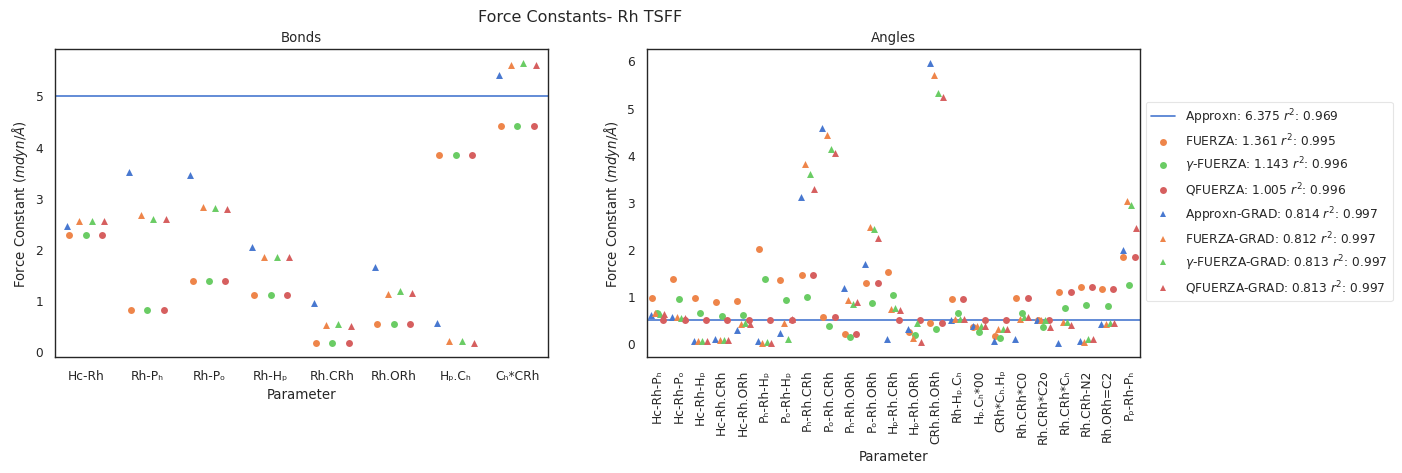

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [15]:
plot_ff_params_v_static(bonds, angles, r2_score_labels[1:], bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=r2_score_labels[0], title='- Rh TSFF')

INCLUDING DONOGHUE

In [16]:
b = bonds+[bond_don]
a = angles+[angle_don]
s = score_sums[1:]+['DONOGHUE: '+'{0:.3f}'.format(donoghue_score)]
b

[  param_type  atom1  atom2  Equilibrium Value  Force Constant  Dipole Moment  \
 0          1      1      2             1.5626          2.2724        -0.4611   
 1          1      2      3             2.3924          0.8141        -6.6928   
 2         a1      2      3             2.2916          1.3697        -5.0068   
 3          1      2      4             1.6253          1.1033        -1.5657   
 4          1      2      6             2.3388          0.1620         1.8318   
 5          1      2      9             2.2247          0.5331         0.6528   
 6          1      4      5             1.7099          3.8474        -1.3716   
 7          1      5      6             1.4222          4.4167        -1.5340   
 
                              FF Parameter  
 0  FUERZA: 1.361 $r^{2}$: 0.995     Hc-Rh  
 1  FUERZA: 1.361 $r^{2}$: 0.995     Rh-Pₕ  
 2  FUERZA: 1.361 $r^{2}$: 0.995     Rh-Pₒ  
 3  FUERZA: 1.361 $r^{2}$: 0.995     Rh-Hₚ  
 4  FUERZA: 1.361 $r^{2}$: 0.995    Rh.CRh  

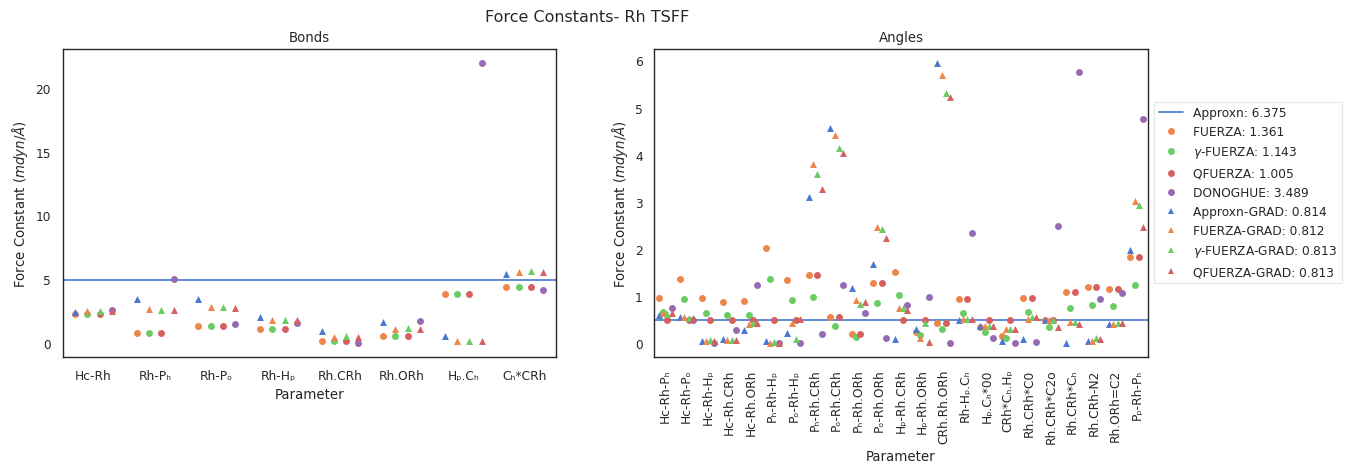

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [17]:
plot_ff_params_v_static(b, a, s, bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

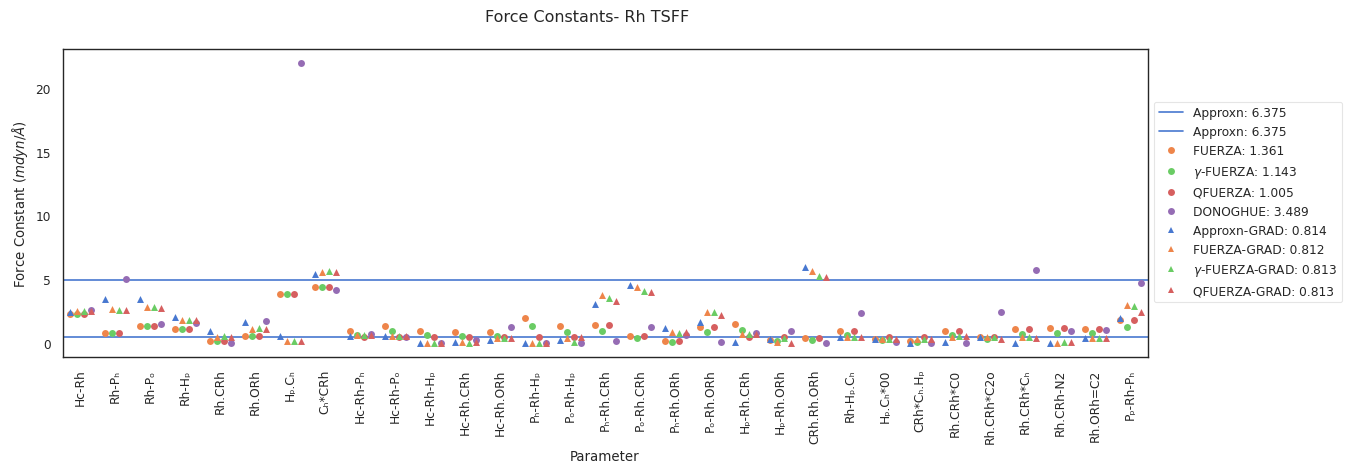

(<Figure size 1400x400 with 1 Axes>,
 <Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>)

In [18]:
plot_ff_params_v_static_(b, a, s, bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

In [19]:
bb = [bond_normal] + b
aa = [angle_normal] + a
ss = score_sums + ['DONOGHUE: '+'{0:.3f}'.format(donoghue_score)]
angle_normal

,param_type,atom1,atom2,atom3,Equilibrium Value,Force Constant,FF,Parameter
0,2,1,2,3,85.4339,0.5,6.3751,Hc-Rh-Pₕ
1,a2,1,2,3,84.3121,0.5,6.3751,Hc-Rh-Pₒ
2,2,1,2,4,84.8617,0.5,6.3751,Hc-Rh-Hₚ
3,2,1,2,6,168.5483,0.5,6.3751,Hc-Rh.CRh
4,2,1,2,9,93.0980,0.5,6.3751,Hc-Rh.ORh
5,2,3,2,4,168.7540,0.5,6.3751,Pₕ-Rh-Hₚ
6,a2,3,2,4,89.4721,0.5,6.3751,Pₒ-Rh-Hₚ
7,2,3,2,6,108.8086,0.5,6.3751,Pₕ-Rh.CRh
8,a2,3,2,6,113.9045,0.5,6.3751,Pₒ-Rh.CRh
9,2,3,2,9,90.4351,0.5,6.3751,Pₕ-Rh.ORh


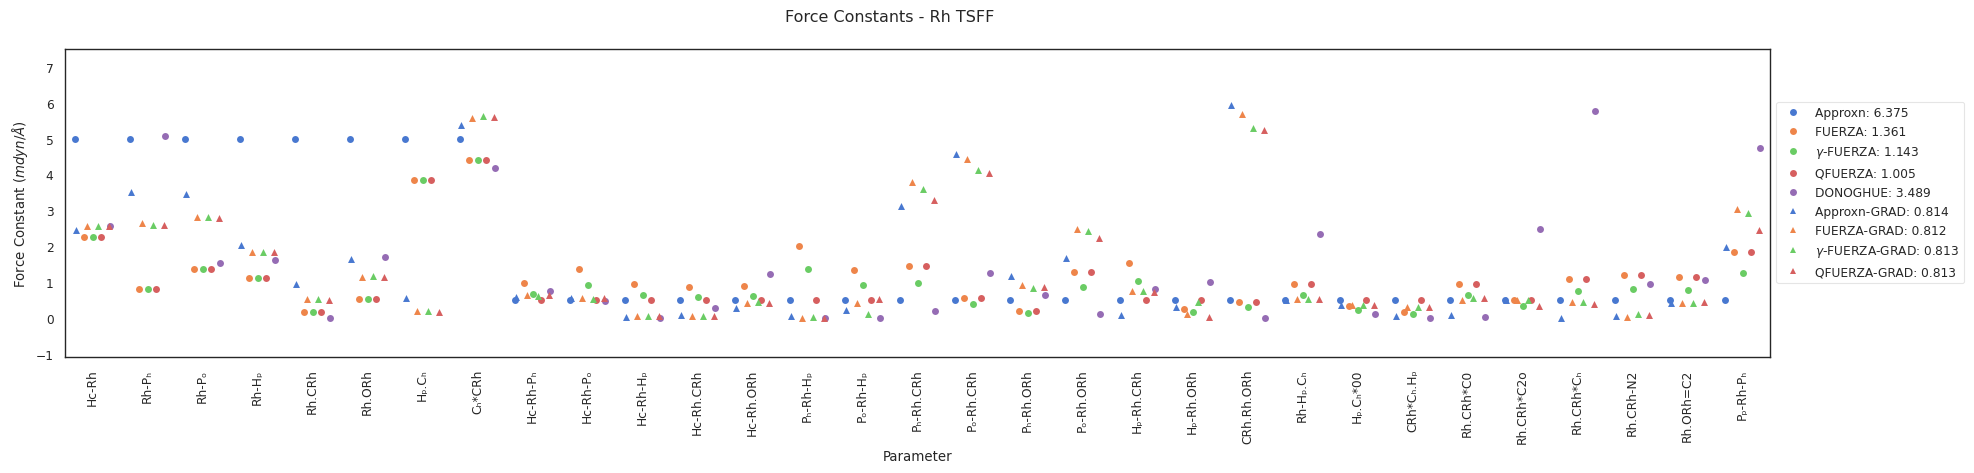

In [20]:
fig, ax = plt.subplots(figsize=(22, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(bb, aa, ss)

seaborn.stripplot(data=param_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

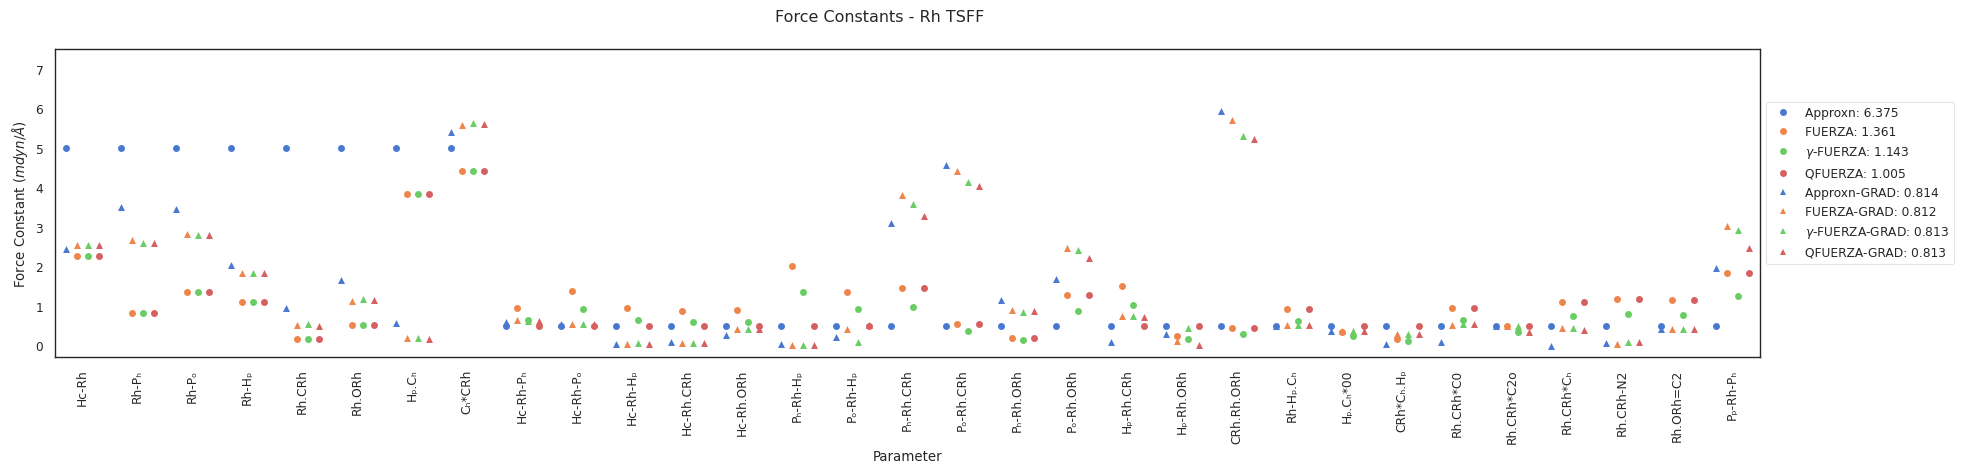

In [21]:
fig, ax = plt.subplots(figsize=(22, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(bb[:-1], aa[:-1], ss[:-1])

seaborn.stripplot(data=param_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

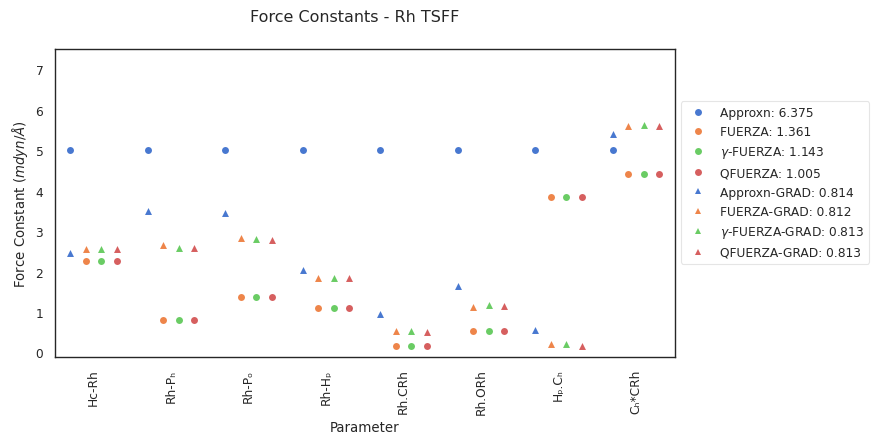

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

bond_unopt, angle_unopt, bond_opt, angle_opt = filter_params_by_type_opt(bb[:-1], aa[:-1], ss[:-1])

seaborn.stripplot(data=bond_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=bond_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

In [23]:
angle_unopt

,param_type,atom1,atom2,atom3,Equilibrium Value,Force Constant,FF,Parameter
0,2,1,2,3,85.4339,0.5000,Approxn: 6.375,Hc-Rh-Pₕ
1,a2,1,2,3,84.3121,0.5000,Approxn: 6.375,Hc-Rh-Pₒ
2,2,1,2,4,84.8617,0.5000,Approxn: 6.375,Hc-Rh-Hₚ
3,2,1,2,6,168.5483,0.5000,Approxn: 6.375,Hc-Rh.CRh
4,2,1,2,9,93.0980,0.5000,Approxn: 6.375,Hc-Rh.ORh
...,...,...,...,...,...,...,...,...
18,2,2,6,C2,111.9420,0.5000,QFUERZA: 1.005,Rh.CRh*C2o
19,2,2,6,5,70.7849,1.0975,QFUERZA: 1.005,Rh.CRh*Cₕ
20,2,2,6,7,104.9803,1.1911,QFUERZA: 1.005,Rh.CRh-N2
21,2,2,9,8,114.8580,1.1558,QFUERZA: 1.005,Rh.ORh=C2


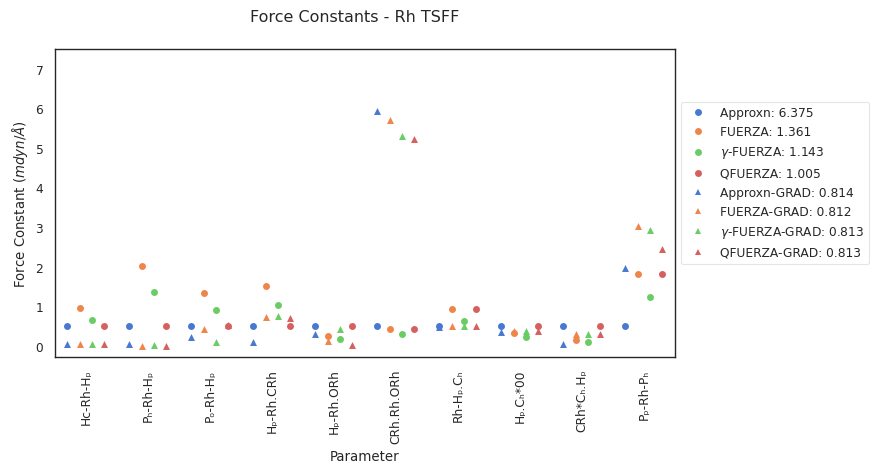

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')
colors_pick = seaborn.color_palette('muted')
#colors_pick = seaborn.color_palette(palette=zesty)

indices = [2, 5, 6, 11, 12, 13, 14, 15, 16, -1]

keep_angles = [angle_label_list[ind] for ind in indices]

angle_unopt = angle_unopt[angle_unopt["Parameter"].isin(keep_angles)]
angle_opt = angle_opt[angle_opt["Parameter"].isin(keep_angles)]

seaborn.stripplot(data=angle_unopt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=angle_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(1.0, 0.85), fancybox=True, framealpha=0.5)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

/tmp/ipykernel_663713/603850001.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  seaborn.stripplot(data=param_unopt.where(param_unopt['atom3'] == None), x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore


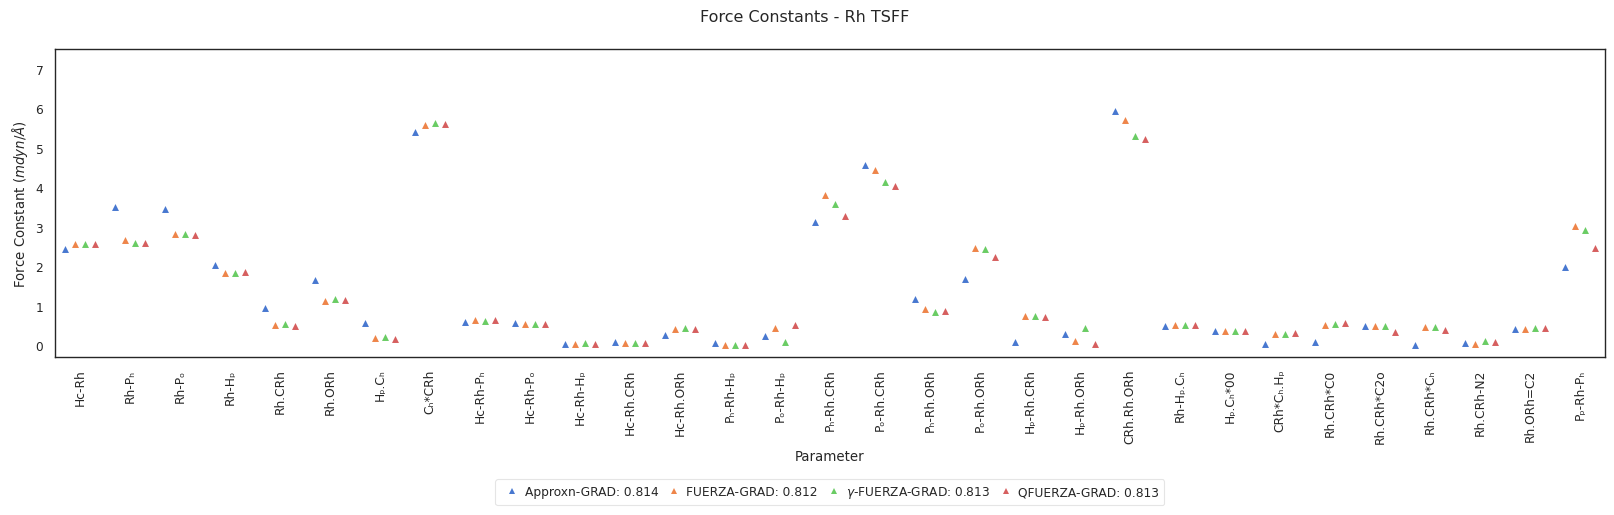

In [25]:
fig, ax = plt.subplots(figsize=(20, 4))
fig.suptitle('Force Constants'+' - Rh TSFF')

colors_pick = seaborn.color_palette('muted')
#colors_pick - seaborn.color_palette(palette=zesty)

param_unopt, param_opt = filter_params_by_opt(bb[:-1], aa[:-1], ss[:-1])

seaborn.stripplot(data=param_unopt.where(param_unopt['atom3'] == None), x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick)) # type: ignore
seaborn.stripplot(data=param_opt, x="Parameter", y="Force Constant", ax=ax, hue="FF", dodge=True, palette=itertools.cycle(colors_pick), marker='^') # type: ignore

plt.xticks(rotation=90)
plt.ylim(top=7.5)
ax.legend(bbox_to_anchor=(0.5, -0.5), loc='lower center', fancybox=True, framealpha=0.5, ncol=8, columnspacing=0.3, handletextpad=0.)
ax.set_ylabel(r'Force Constant ($mdyn/\AA$)')
plt.show()

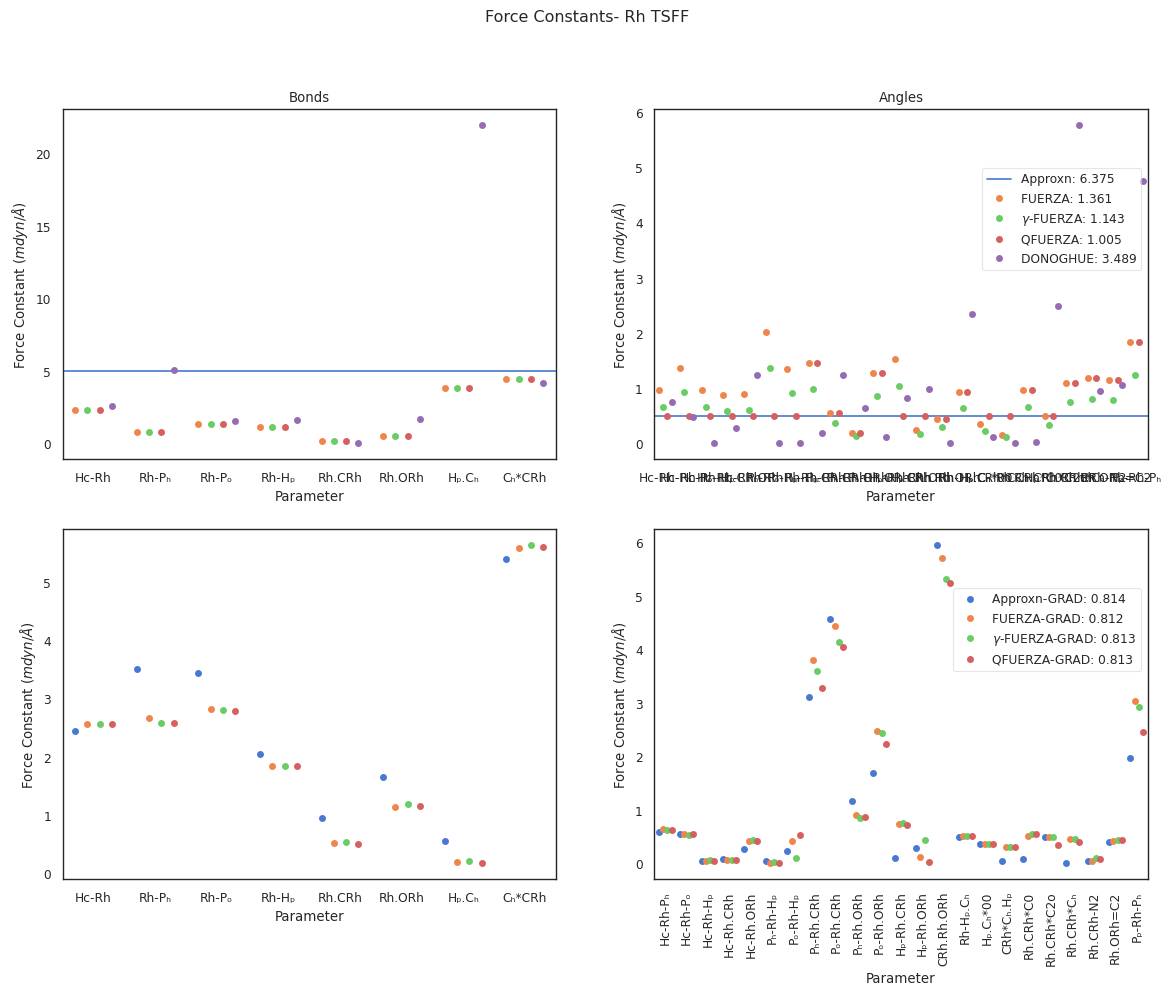

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Bonds'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
         <Axes: title={'center': 'Angles'}, xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
        [<Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
         <Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>]],
       dtype=object))

In [26]:
compare_opt_params(b, a, s, bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')

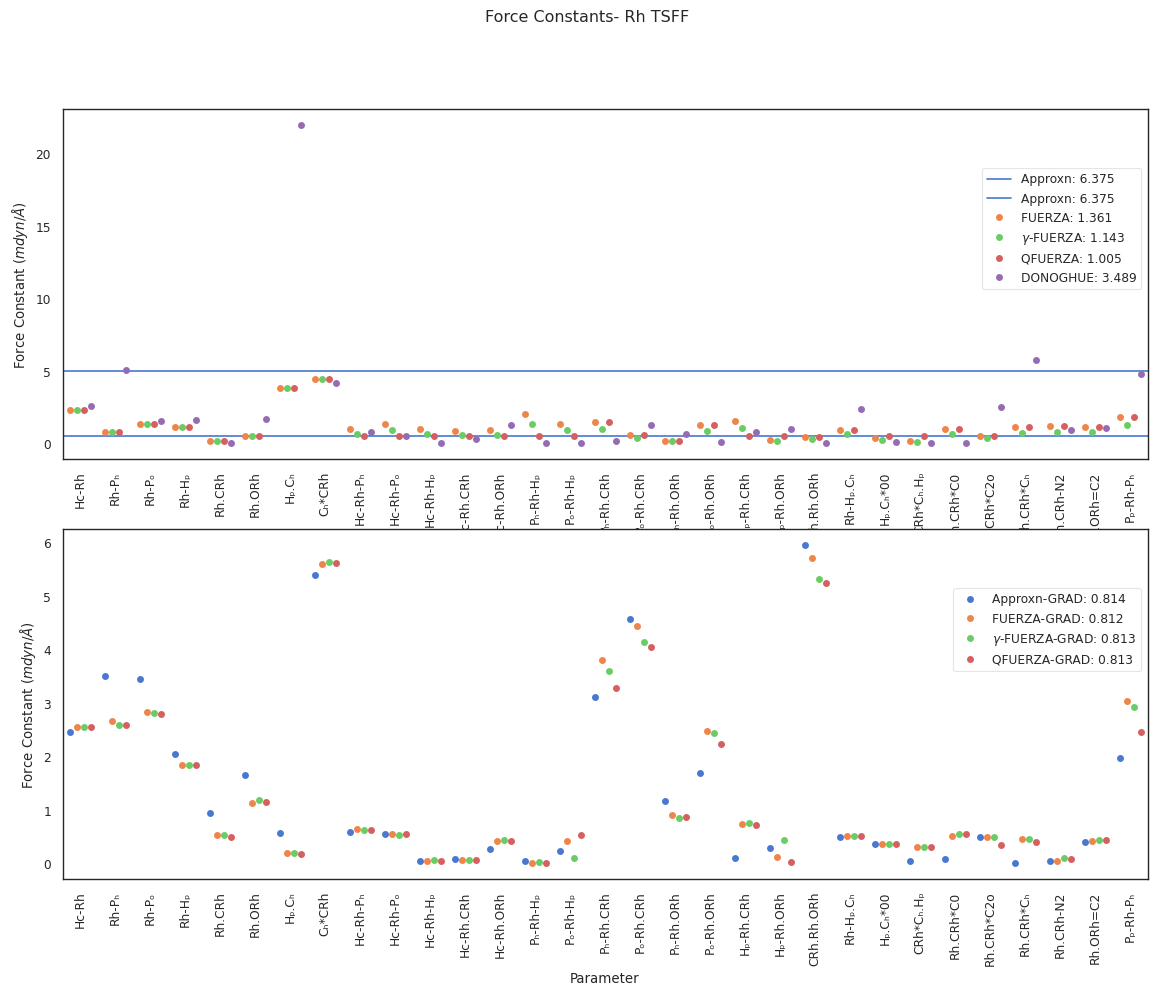

(<Figure size 1400x1000 with 2 Axes>,
 array([<Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>,
        <Axes: xlabel='Parameter', ylabel='Force Constant ($mdyn/\\AA$)'>],
       dtype=object))

In [27]:
compare_opt_params_(b, a, s, bond_labels=bond_label_list, angles_labels=angle_label_list, estimate_score=score_sums[0], title='- Rh TSFF')